# Medical VQA — GPT-5 Mini Open-Ended Captioning

This notebook uses GPT-5 Mini via the OpenAI API for open-ended medical captioning.
Unlike local models (BLIP, BLIP-2, InstructBLIP), GPT-5 Mini runs entirely via API —
no GPU required, no training, just API calls.

**Why GPT-5 Mini:**
- State-of-the-art vision-language understanding
- Instruction-following capability far beyond local models
- ~$1.50 total for 769 validation samples
- No VRAM usage — frees up your GPU entirely

**Estimated cost:** ~$1.50 for full validation set (769 samples)
**Estimated time:** ~20-30 minutes (API rate limits)

## 1. Install Dependencies

In [ ]:
!pip install -q openai datasets pillow evaluate rouge_score tqdm

## 2. Imports

In [1]:
import io
import os
import base64
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from openai import OpenAI
from datasets import load_dataset
import evaluate

RANDOM_STATE = 42
print('Imports ready!')

c:\Users\Micah\Documents\code\Medical_VQA_Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready!


## 3. API Key Setup

In [ ]:
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv('')

client = OpenAI(api_key=OPENAI_API_KEY)

# Quick test to confirm key works
try:
    test = client.models.list()
    print('API key valid!')
except Exception as e:
    print(f'API key error: {e}')

API key valid!
SyncPage[Model](data=[Model(id='text-embedding-ada-002', created=1671217299, object='model', owned_by='openai-internal'), Model(id='whisper-1', created=1677532384, object='model', owned_by='openai-internal'), Model(id='gpt-3.5-turbo', created=1677610602, object='model', owned_by='openai'), Model(id='tts-1', created=1681940951, object='model', owned_by='openai-internal'), Model(id='gpt-3.5-turbo-16k', created=1683758102, object='model', owned_by='openai-internal'), Model(id='gpt-4-0613', created=1686588896, object='model', owned_by='openai'), Model(id='gpt-4', created=1687882411, object='model', owned_by='openai'), Model(id='davinci-002', created=1692634301, object='model', owned_by='system'), Model(id='babbage-002', created=1692634615, object='model', owned_by='system'), Model(id='gpt-3.5-turbo-instruct', created=1692901427, object='model', owned_by='system'), Model(id='gpt-3.5-turbo-instruct-0914', created=1694122472, object='model', owned_by='system'), Model(id='dall-e

## 4. Model and Cost Settings

In [4]:
MODEL_NAME = 'gpt-5-mini-2025-08-07'  # GPT-5 Mini API name

# Pricing (per 1M tokens)
INPUT_COST_PER_1M  = 0.25   # $0.25 per 1M input tokens
OUTPUT_COST_PER_1M = 2.00   # $2.00 per 1M output tokens

# Track running costs
total_input_tokens  = 0
total_output_tokens = 0

def get_running_cost():
    input_cost  = (total_input_tokens  / 1_000_000) * INPUT_COST_PER_1M
    output_cost = (total_output_tokens / 1_000_000) * OUTPUT_COST_PER_1M
    return input_cost + output_cost

print(f'Model: {MODEL_NAME}')
print(f'Input cost:  ${INPUT_COST_PER_1M}/1M tokens')
print(f'Output cost: ${OUTPUT_COST_PER_1M}/1M tokens')

Model: gpt-5-mini-2025-08-07
Input cost:  $0.25/1M tokens
Output cost: $2.0/1M tokens


## 5. Utility Functions

In [5]:
def open_image_from_dataset_value(image_value):
    """Opens an image from different possible HuggingFace/pandas formats."""
    if isinstance(image_value, Image.Image):
        return image_value
    if isinstance(image_value, dict) and image_value.get('bytes') is not None:
        return Image.open(io.BytesIO(image_value['bytes']))
    if isinstance(image_value, dict) and image_value.get('path') is not None:
        return Image.open(image_value['path'])
    return None


def image_to_base64(image):
    """Converts a PIL image to base64 string for the OpenAI API."""
    img = image.convert('RGB')
    buffer = io.BytesIO()
    img.save(buffer, format='JPEG')
    return base64.b64encode(buffer.getvalue()).decode('utf-8')


def normalize_text(x):
    if x is None:
        return None
    return str(x).strip().lower()


def infer_question_type(answer):
    ans = normalize_text(answer)
    if ans in {'yes', 'no'}:
        return 'binary'
    return 'open_ended'


print('Utilities ready!')

Utilities ready!


## 6. Load Dataset and Filter ROCO Subset

In [6]:
dataset = load_dataset('robailleo/medical-vision-llm-dataset')

val_df = dataset['validation'].to_pandas()
val_df['question_type'] = val_df['answer'].apply(infer_question_type)

val_roco = val_df[val_df['question_type'] == 'open_ended'].reset_index(drop=True)

print('Open-ended val size:', len(val_roco))
print('\nSample question:', val_roco['question'].iloc[0])
print('Sample answer:  ', val_roco['answer'].iloc[0])

Open-ended val size: 769

Sample question: what imaging modality was used?
Sample answer:   x-ray


## 7. Evaluation Metrics

In [7]:
bleu  = evaluate.load('bleu')
rouge = evaluate.load('rouge')


def compute_captioning_metrics(predictions, references):
    filtered = [(p, r) for p, r in zip(predictions, references) if p.strip()]
    if not filtered:
        return {'bleu': 0.0, 'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    preds, refs = zip(*filtered)
    preds = list(preds)
    refs  = list(refs)

    bleu_refs   = [[r] for r in refs]
    bleu_score  = bleu.compute(predictions=preds, references=bleu_refs)
    rouge_score = rouge.compute(predictions=preds, references=refs)

    return {
        'bleu':   round(bleu_score['bleu'], 4),
        'rouge1': round(rouge_score['rouge1'], 4),
        'rouge2': round(rouge_score['rouge2'], 4),
        'rougeL': round(rouge_score['rougeL'], 4),
    }


def print_captioning_metrics(metrics, model_name='Model'):
    print(f"\n{'='*40}")
    print(f'  {model_name}')
    print(f"{'='*40}")
    print(f"  BLEU   : {metrics['bleu']:.4f}")
    print(f"  ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"  ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"  ROUGE-L: {metrics['rougeL']:.4f}")
    print(f"{'='*40}\n")


print('Metrics ready!')

Metrics ready!


## 8. GPT-5 Mini Generation Function

Key difference from local models: images are sent as base64 via the API.
We use 'low' detail mode to minimize cost while preserving quality for medical images.

In [26]:
def generate_caption_gpt(image, question, client, model=MODEL_NAME,
                          max_tokens=1500, retries=3):
    global total_input_tokens, total_output_tokens

    img_b64 = image_to_base64(image)

    system_prompt = (
        "You are an expert radiologist interpreting medical images. "
        "Provide concise, accurate, and specific medical descriptions "
        "using precise clinical terminology. Focus only on what is "
        "visible in the image."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{img_b64}",
                        "detail": "low"
                    }
                },
                {
                    "type": "text",
                    "text": question
                }
            ]
        }
    ]

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                max_completion_tokens=1500,
            )

            # Debug
            # print(f'  DEBUG response: {response}')
            # print(f'  DEBUG choices: {response.choices}')
            # print(f'  DEBUG content: {response.choices[0].message.content}')

            total_input_tokens  += response.usage.prompt_tokens
            total_output_tokens += response.usage.completion_tokens

            return response.choices[0].message.content.strip()

        except Exception as e:
            print(f'  DEBUG error (attempt {attempt+1}): {e}')
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                return ''

    return ''

## 9. Sanity Check — 5 Samples

Always run this before the full evaluation.
Cost: ~$0.01 for 5 samples.

In [24]:
sample_df = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)

print('=== Sanity Check — 5 Samples ===\n')
for i, row in sample_df.iterrows():
    img = open_image_from_dataset_value(row['image'])
    if img is None:
        continue

    generated = generate_caption_gpt(img, row['question'], client)

    print(f'--- Sample {i+1} ---')
    print(f'Question:  {row["question"]}')
    print(f'Generated: {generated}')
    print(f'Reference: {row["answer"]}')
    print()

print(f'Cost so far: ${get_running_cost():.4f}')

=== Sanity Check — 5 Samples ===

  DEBUG response: ChatCompletion(id='chatcmpl-DbIbg8ssukCmCwZ6h9tMys0UCK7rK', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The rounded, calcified mass is in the midline pineal region — posterior to the midbrain/dorsal to the cerebral aqueduct.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1777782032, model='gpt-5-mini-2025-08-07', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=294, prompt_tokens=521, total_tokens=815, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=256, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
  DEBUG choices: [Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The rounded, calcifi

## 10. Full Evaluation on Validation Set

Runs GPT-5 Mini on all 769 ROCO validation samples.
Cost tracker prints every 50 samples so you can monitor spend.
Expected total cost: ~$1.50

In [27]:
def run_gpt_evaluation(df, client, model=MODEL_NAME, max_tokens=150,
                        delay=0.5):
    """
    Runs GPT-5 Mini on full dataframe.
    delay: seconds between API calls to avoid rate limits.
    Saves progress to CSV every 50 samples in case of interruption.
    """
    predictions = []
    references  = []
    questions   = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='GPT-5 Mini'):
        img = open_image_from_dataset_value(row['image'])
        if img is None:
            predictions.append('')
            references.append(str(row['answer']))
            questions.append(str(row['question']))
            continue

        generated = generate_caption_gpt(
            img, row['question'], client, model, max_tokens
        )

        predictions.append(generated)
        references.append(str(row['answer']))
        questions.append(str(row['question']))

        # Small delay to avoid rate limits
        time.sleep(delay)

        # Progress + cost update every 50 samples
        if (idx + 1) % 50 == 0:
            print(f'  [{idx+1}/{len(df)}] Running cost: ${get_running_cost():.4f}')

            # Save progress in case of interruption
            progress_df = pd.DataFrame({
                'question':   questions,
                'reference':  references,
                'gpt5mini':   predictions,
            })
            progress_df.to_csv('gpt5mini_progress.csv', index=False)

    return predictions, references, questions


print('Running full GPT-5 Mini evaluation...')
print('Expected cost: ~$1.50 | Expected time: ~20-30 minutes\n')

gpt_preds, gpt_refs, gpt_questions = run_gpt_evaluation(val_roco, client)

metrics_gpt = compute_captioning_metrics(gpt_preds, gpt_refs)
print_captioning_metrics(metrics_gpt, model_name='GPT-5 Mini')
print(f'Total cost: ${get_running_cost():.4f}')

Running full GPT-5 Mini evaluation...
Expected cost: ~$1.50 | Expected time: ~20-30 minutes



GPT-5 Mini:   7%|▋         | 50/769 [10:49<2:14:08, 11.19s/it]

  [50/769] Running cost: $0.0946


GPT-5 Mini:  13%|█▎        | 100/769 [20:41<1:20:34,  7.23s/it]

  [100/769] Running cost: $0.1692


...

  [700/769] Running cost: $1.0652


GPT-5 Mini:  98%|█████████▊| 750/769 [2:01:21<02:36,  8.26s/it]

  [750/769] Running cost: $1.1397


GPT-5 Mini: 100%|██████████| 769/769 [2:04:04<00:00,  9.68s/it]



  GPT-5 Mini
  BLEU   : 0.0088
  ROUGE-1: 0.1215
  ROUGE-2: 0.0279
  ROUGE-L: 0.0943

Total cost: $1.1711


## 11. Full Results Comparison Table

In [28]:
# Hardcoded results from all previous experiments
metrics_blip_zeroshot    = {'bleu': 0.0000, 'rouge1': 0.0518, 'rouge2': 0.0034, 'rougeL': 0.0427}
metrics_blip_finetuned   = {'bleu': 0.0000, 'rouge1': 0.0953, 'rouge2': 0.0097, 'rougeL': 0.0873}
metrics_blip2            = {'bleu': 0.0039, 'rouge1': 0.1409, 'rouge2': 0.0335, 'rougeL': 0.1251}
metrics_instructblip     = {'bleu': 0.0058, 'rouge1': 0.1517, 'rouge2': 0.0400, 'rougeL': 0.1345}

results = pd.DataFrame([
    {'Model': 'BLIP Base Zero-Shot',                       **metrics_blip_zeroshot},
    {'Model': 'BLIP Base Fine-Tuned (Frozen Vision)',      **metrics_blip_finetuned},
    {'Model': 'BLIP-2 OPT-2.7B Zero-Shot',                **metrics_blip2},
    {'Model': 'InstructBLIP vicuna-7b Zero-Shot',          **metrics_instructblip},
    {'Model': 'GPT-5 Mini Zero-Shot',                      **metrics_gpt},
])

print(results.to_string(index=False))
results.to_csv('full_captioning_results.csv', index=False)
print('\nFull results saved to full_captioning_results.csv')

                               Model   bleu  rouge1  rouge2  rougeL
                 BLIP Base Zero-Shot 0.0000  0.0518  0.0034  0.0427
BLIP Base Fine-Tuned (Frozen Vision) 0.0000  0.0953  0.0097  0.0873
           BLIP-2 OPT-2.7B Zero-Shot 0.0039  0.1409  0.0335  0.1251
    InstructBLIP vicuna-7b Zero-Shot 0.0058  0.1517  0.0400  0.1345
                GPT-5 Mini Zero-Shot 0.0088  0.1215  0.0279  0.0943

Full results saved to full_captioning_results.csv


## 12. Results Bar Chart

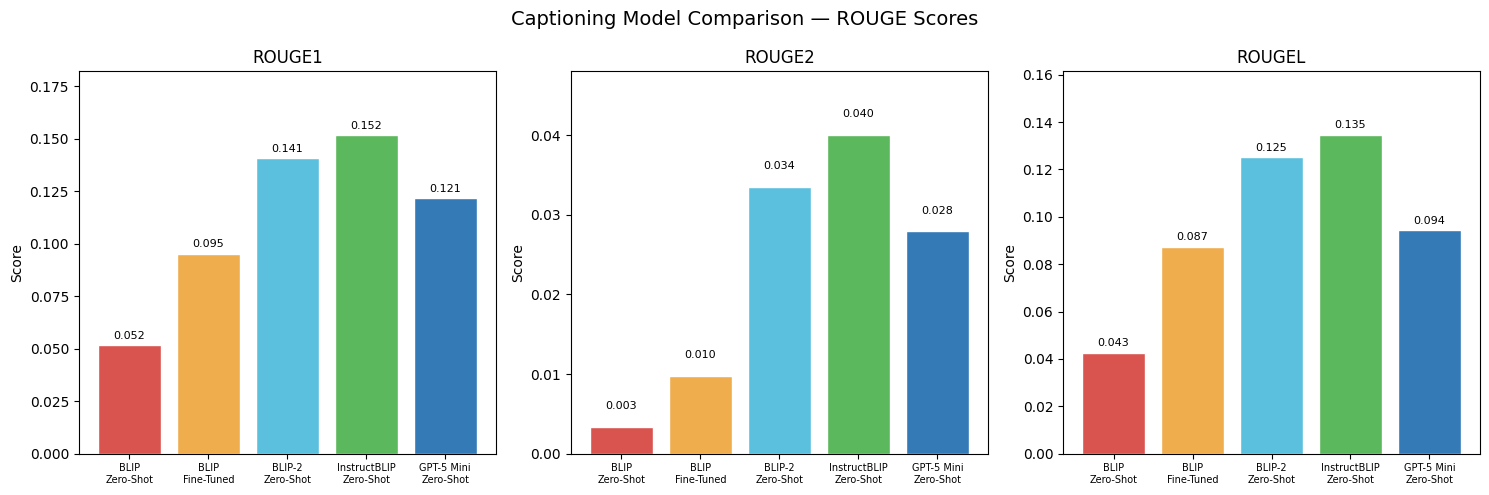

Chart saved to captioning_comparison_chart.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Captioning Model Comparison — ROUGE Scores', fontsize=14)

models = results['Model'].tolist()
short_names = [
    'BLIP\nZero-Shot',
    'BLIP\nFine-Tuned',
    'BLIP-2\nZero-Shot',
    'InstructBLIP\nZero-Shot',
    'GPT-5 Mini\nZero-Shot'
]
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#337ab7']

for ax, metric in zip(axes, ['rouge1', 'rouge2', 'rougeL']):
    values = results[metric].tolist()
    bars = ax.bar(short_names, values, color=colors, edgecolor='white')
    ax.set_title(metric.upper())
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(values) * 1.2)
    ax.tick_params(axis='x', labelsize=7)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('captioning_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to captioning_comparison_chart.png')

## 13. Qualitative Sample Predictions

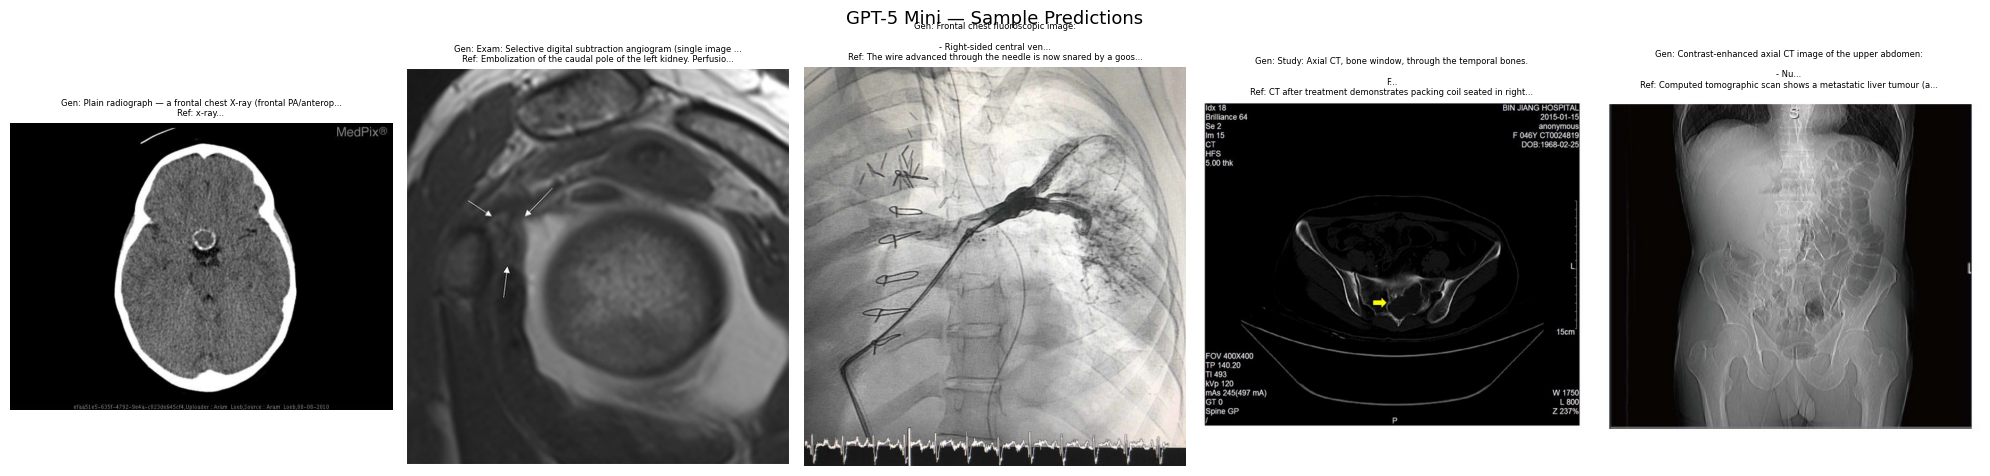

In [30]:
sample_df   = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)
sample_idxs = sample_df.index.tolist()

sample_preds = [gpt_preds[i] for i in sample_idxs]
sample_refs  = [gpt_refs[i]  for i in sample_idxs]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('GPT-5 Mini — Sample Predictions', fontsize=13)

for i, ax in enumerate(axes):
    img = open_image_from_dataset_value(sample_df.iloc[i]['image'])
    ax.imshow(img.convert('RGB'))
    ax.axis('off')
    title = f"Gen: {sample_preds[i][:60]}...\nRef: {sample_refs[i][:60]}..."
    ax.set_title(title, fontsize=6, wrap=True)

plt.tight_layout()
plt.savefig('gpt5mini_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print('\n=== GPT-5 Mini Sample Predictions vs References ===\n')
for i, (pred, ref) in enumerate(zip(sample_preds, sample_refs)):
    print(f'--- Sample {i+1} ---')
    print(f'Question:  {sample_df.iloc[i]["question"]}')
    print(f'Generated: {pred}')
    print(f'Reference: {ref}')
    print()


=== GPT-5 Mini Sample Predictions vs References ===

--- Sample 1 ---
Question:  where is the mass located?
Generated: Plain radiograph — a frontal chest X-ray (frontal PA/anteroposterior chest radiograph).
Reference: x-ray

--- Sample 2 ---
Question:  Describe the medical findings in this image.
Generated: Exam: Selective digital subtraction angiogram (single image provided).

Findings:
- Catheter projects within a single feeding artery supplying a well‑circumscribed, round area of intense contrast enhancement (dense "tumor blush").
- Multiple radiating/branching arterial feeders are visible coursing into the lesion.
- No definite early venous drainage or active extravasation is identified on this view.

Impression:
- Dense, spherical hypervascular lesion with multiple arterial feeders arising from the catheterized artery — imaging appearance consistent with a hypervascular tumor/vascular lesion. Correlate with cross‑sectional imaging and clinical information for anatomic localizatio

## 14. Cost Summary

In [32]:
input_cost  = (total_input_tokens  / 1_000_000) * INPUT_COST_PER_1M
output_cost = (total_output_tokens / 1_000_000) * OUTPUT_COST_PER_1M
total_cost  = input_cost + output_cost

print(f'\n=== Cost Summary ===')
print(f'Total input tokens:  {total_input_tokens:,}')
print(f'Total output tokens: {total_output_tokens:,}')
print(f'Input cost:          ${input_cost:.4f}')
print(f'Output cost:         ${output_cost:.4f}')
print(f'Total cost:          ${total_cost:.4f}')


=== Cost Summary ===
Total input tokens:  463,668
Total output tokens: 527,612
Input cost:          $0.1159
Output cost:         $1.0552
Total cost:          $1.1711


## 15. Save All Predictions

In [33]:
final_df = pd.DataFrame({
    'question':  gpt_questions,
    'reference': gpt_refs,
    'gpt5mini':  gpt_preds,
})

final_df.to_csv('gpt5mini_all_predictions.csv', index=False)
print('Saved: gpt5mini_all_predictions.csv')
print('Saved: full_captioning_results.csv')
print('Saved: captioning_comparison_chart.png')
print('Saved: gpt5mini_sample_predictions.png')

Saved: gpt5mini_all_predictions.csv
Saved: full_captioning_results.csv
Saved: captioning_comparison_chart.png
Saved: gpt5mini_sample_predictions.png
